In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import root_mean_squared_error
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold

DATA_DIR = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction") 

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

In [2]:
def load_horizontal(well_id, split="train"):
    dir_ = TRAIN_DIR if split == "train" else TEST_DIR
    fn = dir_ / f"{well_id}__horizontal_well.csv"
    df = pd.read_csv(fn)
    df = df.sort_values("MD").reset_index(drop=True)
    return df

In [3]:
def load_typewell(well_id, split="train"):
    dir_ = TRAIN_DIR if split == "train" else TEST_DIR
    fn = dir_ / f"{well_id}__typewell.csv"
    df = pd.read_csv(fn)
    df = df.sort_values("TVT").reset_index(drop=True)
    return df

In [4]:
def list_wells(split="train"):
    dir_ = TRAIN_DIR if split == "train" else TEST_DIR
    files = sorted(dir_.glob("*__horizontal_well.csv"))
    return [f.name.split("__")[0] for f in files]

In [5]:
def baseline_tvt_prediction(h_df: pd.DataFrame) -> pd.Series:
    """
    h_df: horizontal well df with columns ['MD','TVT','TVT_input'] in train,
          or ['MD','TVT_input'] in test (TVT is NaN there).
    Returns a Series of baseline TVT predictions for all rows.
    """
    df = h_df.sort_values("MD").reset_index(drop=True)
    pred = df["TVT_input"].copy()

    known = ~pred.isna()
    # if almost nothing known, fallback (train only)
    if ("TVT" in df.columns) and known.sum() < 2:
        return df["TVT"].copy()
    if ("TVT" not in df.columns) and known.sum() < 2:
        # test with almost no TVT_input: fallback to flat baseline
        mean_val = df["TVT_input"].dropna().mean() if df["TVT_input"].notna().any() else 0.0
        return pd.Series(mean_val, index=df.index)

    md_known = df.loc[known, "MD"].values
    tvt_known = df.loc[known, "TVT_input"].values
    md_all = df["MD"].values

    interp_all = np.interp(md_all, md_known, tvt_known)
    pred[~known] = interp_all[~known]
    return pred

In [6]:
def add_basic_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # per-well relative MD
    md_min, md_max = df["MD"].min(), df["MD"].max()
    df["MD_rel"] = (df["MD"] - md_min) / (md_max - md_min + 1e-6)

    # distance from geological surfaces
    surface_cols = ["ANCC", "ASTNU", "ASTNL", "EGFDU", "EGFDL", "BUDA"]
    for col in surface_cols:
        if col in df.columns:
            df[f"Z_minus_{col}"] = df["Z"] - df[col]

    # GR handling
    if "GR" in df.columns:
        df["GR_isna"] = df["GR"].isna().astype(int)
        df["GR_filled"] = df["GR"].ffill().bfill()
    else:
        df["GR_isna"] = 1
        df["GR_filled"] = 0.0

    return df

In [7]:
def add_gr_context_features(df: pd.DataFrame, window=(3, 7, 15, 31)) -> pd.DataFrame:
    df = df.copy()
    g = df["GR_filled"]
    q05, q95 = g.quantile([0.05, 0.95])
    df["GR_high_flag"] = (g > q95).astype(int)
    df["GR_low_flag"] = (g < q05).astype(int)

    for w in window:
        df[f"GR_roll_mean_{w}"] = g.rolling(w, center=True, min_periods=1).mean()
        df[f"GR_roll_std_{w}"] = g.rolling(w, center=True, min_periods=1).std().fillna(0)
        df[f"GR_volatility_{w}"] = g.diff().abs().rolling(w, center=True, min_periods=1).sum()
        df[f"GR_trend_{w}"] = g.rolling(w, center=True, min_periods=1).apply(lambda x: x.iloc[-1] - x.iloc[0])
    
    df["GR_diff"] = g.diff().fillna(0)
    df["GR_diff_abs"] = df["GR_diff"].abs()

    return df

In [8]:
def add_trajectory_derivatives(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in ["X", "Y", "Z"]:
        if col in df.columns:
            df[f"d{col}"] = df[col].diff().fillna(0)
    df["step_length"] = np.sqrt(
        df.get("dX", 0)**2 + df.get("dY", 0)**2 + df.get("dZ", 0)**2
    )
    df["dMD"] = df["MD"].diff().fillna(1.0)
    df["inc"] = np.arctan2(-df["dZ"], np.sqrt(df["dX"]**2 + df["dY"]**2 + 1e-6))
    df["azimuth"] = np.arctan2(df["dY"], df["dX"] + 1e-6)

    df["dinc"] = df["inc"].diff().fillna(0)
    df["dazimuth"] = df["azimuth"].diff().fillna(0)
    df["curvature"] = np.sqrt(df["dinc"]**2 + df["dazimuth"]**2) / df["dMD"].replace(0, 1)
    return df

In [9]:
def build_features_for_well(h: pd.DataFrame) -> pd.DataFrame:
    df = h.sort_values("MD").reset_index(drop=True)
    df = add_basic_features(df)
    df = add_gr_context_features(df)
    df = add_trajectory_derivatives(df)
    return df

In [10]:
def build_residual_training_df_for_well(well_id: str) -> pd.DataFrame:
    h = load_horizontal(well_id, split="train")
    h = h.sort_values("MD").reset_index(drop=True)

    # baseline TVT using TVT_input
    h["TVT_baseline"] = baseline_tvt_prediction(h)

    # residual target
    h["TVT_residual"] = h["TVT"] - h["TVT_baseline"]

    # features
    df = build_features_for_well(h)
    df["TVT_residual"] = h["TVT_residual"]
    df["TVT_baseline"] = h["TVT_baseline"]
    df["TVT"] = h["TVT"]
    df["well_id"] = well_id
    return df

In [11]:
train_wells = list_wells(split="train")
well_ids = np.array(train_wells)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = []
fold_scores = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(well_ids)):
    tr_wells = well_ids[tr_idx]
    va_wells = well_ids[va_idx]

    tr_parts, va_parts = [], []
    for w in tr_wells:
        tr_parts.append(build_residual_training_df_for_well(w))
    for w in va_wells:
        va_parts.append(build_residual_training_df_for_well(w))

    tr_df = pd.concat(tr_parts, ignore_index=True)
    va_df = pd.concat(va_parts, ignore_index=True)

    feature_cols = [
        c for c in tr_df.columns
        if c not in [
            "TVT", "TVT_input", "TVT_residual",
            "TVT_baseline", "well_id"
        ]
    ]

    X_tr = tr_df[feature_cols]
    y_tr = tr_df["TVT_residual"]
    X_va = va_df[feature_cols]
    y_va = va_df["TVT_residual"]

    model = LGBMRegressor(
        n_estimators=1500,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=fold
    )
    model.fit(X_tr, y_tr)

    residual_pred = model.predict(X_va)

    # reconstruct full TVT prediction
    va_df["TVT_pred"] = residual_pred + va_df["TVT_baseline"]

    rmse = root_mean_squared_error(va_df["TVT"], va_df["TVT_pred"])
    fold_scores.append(rmse)
    print(f"Fold {fold}: RMSE={rmse:.3f}")

    models.append(model)

print("Residual model CV RMSE mean:",
      np.mean(fold_scores),
      "std:", np.std(fold_scores))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.395351 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11642
[LightGBM] [Info] Number of data points in the train set: 4048218, number of used features: 50
[LightGBM] [Info] Start training from score 1.386683
Fold 0: RMSE=15.414
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.373620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11641
[LightGBM] [Info] Number of data points in the train set: 4060149, number of used features: 50
[LightGBM] [Info] Start training from score 1.417326
Fold 1: RMSE=12.819
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.392386 seconds.
You can set `force_row_wise=true` to r

In [31]:
y_tr.head(5000)

0        0.00
1        0.00
2        0.00
3        0.00
4        0.00
        ...  
4995   -11.35
4996   -11.34
4997   -11.33
4998   -11.32
4999   -11.31
Name: TVT_residual, Length: 5000, dtype: float64

In [12]:
y_tr.describe()

count    4.078423e+06
mean     7.914548e-01
std      1.409671e+01
min     -1.037800e+02
25%     -3.870000e+00
50%      0.000000e+00
75%      5.480000e+00
max      9.892000e+01
Name: TVT_residual, dtype: float64

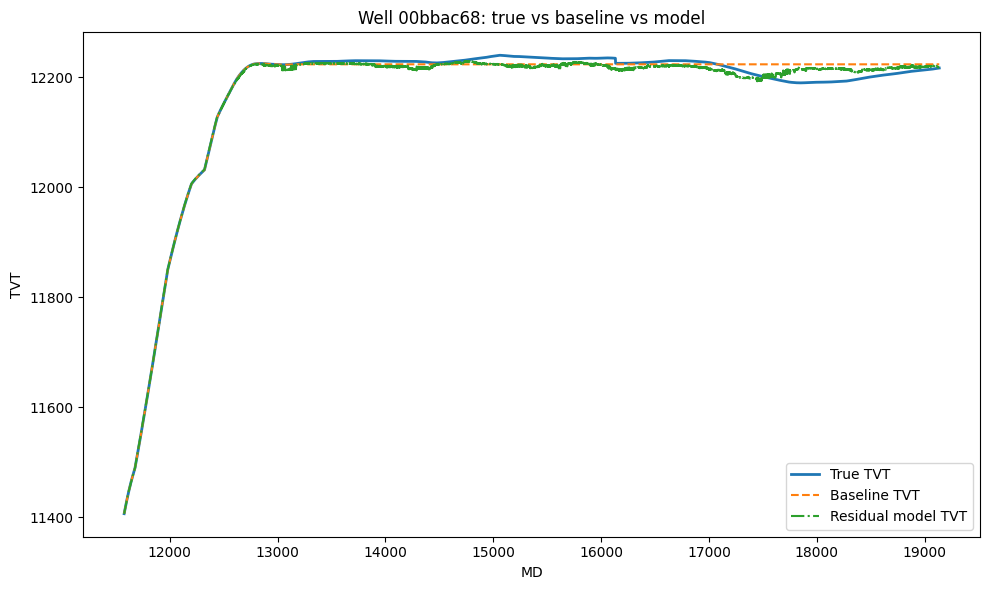

In [13]:
import matplotlib.pyplot as plt

# Example: visualize first val well of last fold
example_well = va_wells[0]
h = load_horizontal(example_well, split="train")
h = h.sort_values("MD").reset_index(drop=True)
h["TVT_baseline"] = baseline_tvt_prediction(h)
df_feat = build_features_for_well(h)
X_example = df_feat[feature_cols]

resid_example = models[-1].predict(X_example)
h["TVT_pred"] = h["TVT_baseline"] + resid_example

plt.figure(figsize=(10, 6))
plt.plot(h["MD"], h["TVT"], label="True TVT", linewidth=2)
plt.plot(h["MD"], h["TVT_baseline"], label="Baseline TVT", linestyle="--")
plt.plot(h["MD"], h["TVT_pred"], label="Residual model TVT", linestyle="-.")
plt.xlabel("MD")
plt.ylabel("TVT")
plt.title(f"Well {example_well}: true vs baseline vs model")
plt.legend()
plt.tight_layout()
plt.show()